# Linear Regression from Scratch: The Mathematical Foundation

Welcome to Week 2! Today, I am diving under the hood of Linear Regression. Instead of just using pre-built libraries, I wanted to understand the actual math behind how a machine learning model "learns" the line of best fit, and then build it entirely from scratch using NumPy.

As a first-year student, moving from basic algebra to matrix operations is a big step, but it makes handling data much more efficient. Let's break down the theory before jumping into the code.

## 1. The Core Idea: Minimizing the Error (RSS)

In simple linear regression, our goal is to find a line equation $y = mx + b$ that best fits our data. But how do we define "best fit"? 

We do this by looking at the errors—the difference between the actual data points ($y_i$) and the points predicted by our line ($\hat{y}_i$). To penalize larger errors and prevent positive and negative errors from canceling each other out, we square them. This gives us the **Residual Sum of Squares (RSS)**:

$$RSS = \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

Substituting our line equation, the loss function we want to minimize is:

$$RSS = \sum_{i=1}^n (y_i - (mx_i + b))^2$$

## 2. The Matrix Approach

Calculating the sum using a loop is fine for a small scale, but when we have thousands of data points or multiple features ($y = m_1x_1 + m_2x_2 + \dots + b$), standard sums become incredibly slow and messy.

Instead, we can represent our entire dataset as a matrix calculation. 
- We package all our inputs into a design matrix $X$ (adding a column of 1s to account for the intercept $b$).
- We package our parameters (intercept and slopes) into a vector $\beta$.

So, our prediction becomes a clean matrix multiplication:
$$\hat{y} = X\beta$$

And our RSS formula transforms into its matrix equivalent:
$$RSS(\beta) = (y - X\beta)^T(y - X\beta)$$

## 3. Finding the Optimal Coefficients (Closed-Form Solution)

To find the best parameters ($\beta$) that minimize our RSS loss function, we need to take the derivative of the matrix equation with respect to $\beta$ and set it to zero.

Expanding the RSS equation gives us:
$$RSS(\beta) = y^Ty - 2\beta^T X^T y + \beta^T X^T X \beta$$

Taking the derivative and setting it to $0$ to find the minimum loss:
$$\frac{\partial (RSS)}{\partial \beta} = -2X^Ty + 2X^TX\beta = 0$$

Which simplifies to:
$$X^TX\beta = X^Ty$$

**The Matrix "Division" Trick:**
In standard math, to isolate $\beta$, we would just divide both sides by $X^TX$. However, in matrix algebra, division doesn't work that way. Instead, we multiply both sides by the **inverse** of $X^TX$, written as $(X^TX)^{-1}$.

This gives us the final Normal Equation—the exact formula to calculate our optimal parameters:
$$\beta = (X^TX)^{-1} X^T y$$

Now that the math is sorted, let's translate this exact equation into Python!

#  Implementation, Testing, and Validation

Now that we have established the mathematical groundwork, it's time to build our custom linear regression model using pure NumPy. 

### How the Custom Model is Structured:
1. **`fit(X, y)`**: This method takes our input features and targets. It automatically adds a column of $1$s to the input matrix $X$ to handle the bias/intercept ($b$). Then, it calculates the optimal parameters vector $\beta$ using the exact closed-form solution we derived: $\beta = (X^TX)^{-1} X^T y$.
2. **`predict(X)`**: Once the model is trained and holds the optimal $\beta$ values, this method adds a column of $1$s to any new incoming data and performs the matrix multiplication $X\beta$ to return the predictions.

After defining our class, we will fetch a real-world dataset, train our model, and validate its accuracy against the industry-standard `scikit-learn` library.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

class LinearRegressionClosed:
    def __init__(self):
        self.beta = None
        self.intercept_ = None
        self.coef_ = None

    def fit(self, X, y):
        if len(X.shape) == 1:
            X = X.reshape(-1, 1)
        y = y.reshape(-1, 1)
        
        # Add a column of ones to X to represent the intercept term (b)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        
        # Calculate beta using the Normal Equation: (X^T * X)^(-1) * X^T * y
        self.beta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        
        # Separate the intercept and the slopes for easy comparison later
        self.intercept_ = self.beta[0][0]
        self.coef_ = self.beta[1:].flatten()
        
    def predict(self, X):
        if len(X.shape) == 1:
            X = X.reshape(-1, 1)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return X_b @ self.beta

## Loading a Real-World Dataset

We are loading the California Housing dataset. To keep our visualization simple and intuitive, we will use a single feature: **MedInc** (Median Income in tens of thousands of dollars) to predict our target **MedHouseVal** (Median House Value in hundreds of thousands of dollars).

In [3]:
housing = fetch_california_housing()

# 2. Use 'MedInc' (Column 0) as our single feature X, and the target as y
X = housing.data[:, 0].reshape(-1, 1)
y = housing.target

# Take a subset of 200 points for a cleaner,visual plot
X_sample = X[:200]
y_sample = y[:200]

# 3. Instantiate 
custom_model = LinearRegressionClosed()
custom_model.fit(X_sample, y_sample)

print("--- Custom Model Trained ---")
print(f"Custom Intercept (b): {custom_model.intercept_:.4f}")
print(f"Custom Coefficient (m): {custom_model.coef_[0]:.4f}")

--- Custom Model Trained ---
Custom Intercept (b): 0.7465
Custom Coefficient (m): 0.3849


## Validating the Work with Scikit-Learn

To ensure our custom math and matrix operations are 100% correct, we will train a standard `LinearRegression` model from `scikit-learn` on the exact same data and compare the resulting parameters.

In [4]:
# 1. Instantiate and train the scikit-learn model
sklearn_model = LinearRegression()
sklearn_model.fit(X_sample, y_sample)

# 2. Print comparisons to check if they match perfectly
print("--- Validation Metrics ---")
print(f"Sklearn Intercept:    {sklearn_model.intercept_:.4f}  |  Custom Intercept:    {custom_model.intercept_:.4f}")
print(f"Sklearn Coefficient:  {sklearn_model.coef_[0]:.4f}  |  Custom Coefficient:  {custom_model.coef_[0]:.4f}")

# 3. Compare predictions
custom_preds = custom_model.predict(X_sample).flatten()
sklearn_preds = sklearn_model.predict(X_sample)

mse_difference = mean_squared_error(custom_preds, sklearn_preds)
print(f"\nMean Squared Difference between predictions: {mse_difference}")
if np.allclose(custom_preds, sklearn_preds):
    print("🚀 Validation Successful!")
else:
    print("❌ There is a mismatch between the models.")

--- Validation Metrics ---
Sklearn Intercept:    0.7465  |  Custom Intercept:    0.7465
Sklearn Coefficient:  0.3849  |  Custom Coefficient:  0.3849

Mean Squared Difference between predictions: 1.732350873816986e-30
🚀 Validation Successful! The custom model matches Scikit-Learn perfectly up to floating-point precision!


## Visualizing the Regression Line

Now let's plot our sample data points alongside the line generated by our custom algorithm to see how beautifully it captures the trend.

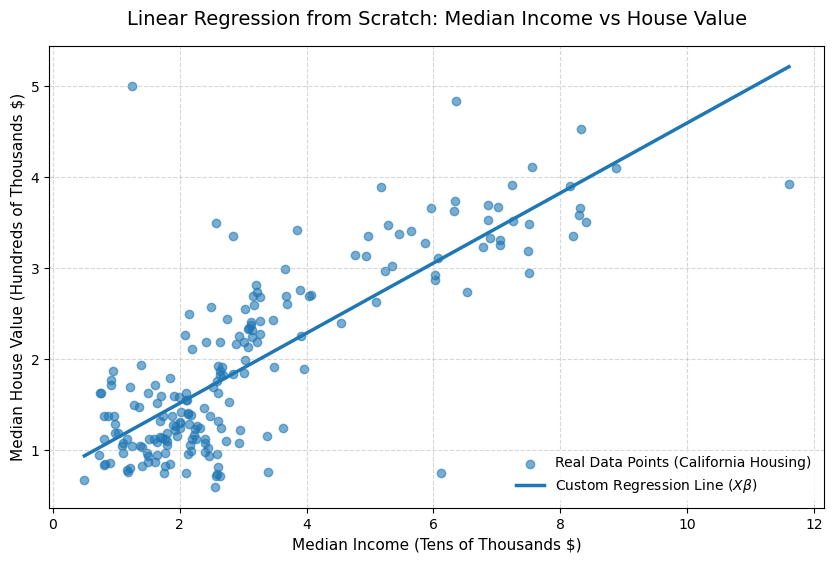

In [5]:
# Generate a range of values for a smooth line plot
X_line = np.linspace(X_sample.min(), X_sample.max(), 100).reshape(-1, 1)
y_line_preds = custom_model.predict(X_line)

# Create the plot
plt.figure(figsize=(10, 6), dpi=100)
plt.scatter(X_sample, y_sample, alpha=0.6, label='Real Data Points (California Housing)')
plt.plot(X_line, y_line_preds, label='Custom Regression Line ($X\\beta$)', linewidth=2.5)

# Style the chart to look professional
plt.title('Linear Regression from Scratch: Median Income vs House Value', fontsize=14, pad=15)
plt.xlabel('Median Income (Tens of Thousands $)', fontsize=11)
plt.ylabel('Median House Value (Hundreds of Thousands $)', fontsize=11)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.show()